<center>
    <h1></h1>
    <h1><b>OCES 5303</b></h1>
    <h2>Assignment 2</h2>
    <hr>
    <p>Jonas Mathisrud Sterud</p>
    <p>21335836</p>
</center>

<center>
    <h1></h1>
    <h3><i>Abstract</i></h3>
    <p>
    Abstrac here.
    <small style="margin-left: 1em">[1]</small>
    </p>
    <p>
    In this assignment, we will explore the dataset, and perform ...
    </p>
    <img src="./figures/cover.jpg" width="50%">
</center>

<h1>The Data</h1>

<p>
The dataset which we'll look at in this assignment, has been supplied by Charmaine Yung <sup><small>[1]</small></sup>, from one of the papers <sup><small>[2]</small></sup> she contributed to.
</p>

<p>
It's data collected at ... using ...,
</p>

<p>
We'll explore the dataset, and create a neural network model that'll hopefully tell us a bit more about how the abundance of bacteria is affected by the temperature, seasons, etc.
</p>

In [1]:
#! This is code from the previous assignment.

#####################################
#       You might need to restart   #
#           the kernel after        #
#           running this cell.      #
#####################################

## Detect environment

try:
    import google.colab # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

## Clone repository and download dependencies
## (assumes using Conda if not in Google Colab)

if IN_COLAB:
    None
    !git clone https://github.com/jonassterud/OCES5303_A2.git
    !cp -r OCES5303_A2/* .
    %pip install -q -r ./requirements.txt
else:
    None
    %conda install -c conda-forge -c pytorch -qq --file ./requirements.txt

Retrieving notices: ...working... done
Channels:
 - conda-forge
 - pytorch
 - defaults
Platform: linux-64
Solving environment: ...working... done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [2]:
## Imports

import numpy as np
import pandas as pd
import plotly.io as pio
import plotly.express as px
import matplotlib.pyplot as plt
import torch
import os

from plotly.subplots import make_subplots
from sklearn import set_config
from sklearn.preprocessing import MinMaxScaler, StandardScaler, FunctionTransformer, OneHotEncoder, PolynomialFeatures, SplineTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.dummy import DummyRegressor
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, PredictionErrorDisplay
from sklearn.cluster import KMeans
from torch import nn
from skorch import NeuralNetRegressor

## Configuration

# set_config(transform_output = "pandas")
pio.templates.default = "plotly_dark"
seed = 9000 + 1
_ = torch.manual_seed(seed)

<h1>Parsing</h1>

<p>
The dataset, which contains 151 samples, has the following variables:
</p>

<ul>
    <li><code>YearDay</code>: Day of the year</li>
    <li><code>Bacteria_abundance</code>: Number of bacteria cells</li>
    <li><code>Projected_Daily_Insolation</code>: Solar heating</li>
    <li><code>Temp</code>: Sea Temperature (℃)</li>
    <li><code>MLLW</code>: Low of the tide TODO?</li>
    <li><code>Salinity</code>: Practical Salinity (PSU)</li>
    <li><code>Oxygen_Saturation</code>: ...</li>
    <li><code>pH</code>: pH level.</li>
    <li><code>DIC</code>: ...</li>
    <li><code>Chlorophyll</code>: ...</li>
    <li><code>NH4</code>: ...</li>
    <li><code>NO2.NO3</code>: ...</li>
    <li><code>PO4</code>: ...</li>
    <li><code>SiO4</code>: ...</li>
    
</ul>

<p>
We load the data from a <code>.txt</code> file into a Pandas <code>DataFrame</code>.
Here, we'll also drop the <code>SampleID</code> variable, since this is just an identifier for the sample, and won't be any useful for our model.
</p>

<p>
Additionaly, we see that the values of <code>YearDay</code> is linear. In reality, years are, of course, cyclical. We'll handle this later.
</p>

In [3]:
df = pd.read_csv("./data/PIDweekly_env_data.txt", sep=r"\s+")
df["YearDay"] = df["YearDay"].astype(float) 
df = df.drop(columns=["SampleID"])

<h1>Split Data</h1>

<p>
First, we'll split the data up into two disjoint subsets: train and test.
</p>

<p>
We'll use the training set for explorative data analysis and training our neural network models.
</p>

<p>
To avoid overfitting (i.e. not being able to generalize), we'll use cross validation to get an unbiased performance. +++
</p>

<p>
Finally, to get a totally unbiased performance metric of our final model, we'll check the generalization error on our test set.
</p>

In [70]:
## Split data (85%, 15%)

X = df.drop(columns = ["Bacteria_abundance"])
y = df["Bacteria_abundance"]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.85, random_state = seed)

## Combined train set (for visualization)

Xy_train = pd.concat([X_train, y_train], axis=1)

# Use periodic spline features:
# https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html#periodic-spline-features

<h1>Exploratory Data Analysis</h1>

<p>
...
</p>

<h1>Cyclic Features</h1>

<p>
As previously mentioned, we're dealing with some cyclic data.
We have the <code>YearDay</code> variable, which tells us which day of the year the observation happened. The values here are linear, so in order to make them cyclic, we have to transform them.
</p>

<p>
Now, there's a variety of transformation methods for this, but here we'll use a periodic spline transformer. <sup><small>[3]</small></sup>
</p>

In [56]:
## Create spline transformer

_t_cyclic = SplineTransformer(
    degree=365,
    n_knots=365 + 1, # Include bias term (+ 1)
    knots=np.linspace(0, 365, 365 + 1).reshape(365 + 1, 1),
    extrapolation="periodic",
    include_bias=True,
)

t_cyclic = ColumnTransformer(
    [("cyclic", _t_cyclic, ["YearDay"])],
    remainder="passthrough",
    verbose_feature_names_out=False
)

<h1>Tensors</h1>

<p>
Now, let's create a transformer that can turn our <code>DataFrame</code> into something more suitable for Pytorch - tensors.
</p>

In [14]:
## Transformation

def _add_tensors(data):
    data_c = data.copy()
    data_c = torch.from_numpy(np.array(data_c)).type(torch.float32)

    return data_c

t_tensors = FunctionTransformer(func=_add_tensors)

# ## Transformation for y

# def _add_tensors_y(data):
#     data_c = data.copy()
#     data_c = torch.from_numpy(np.array(data_c)).type(torch.float32).view(-1, 1)

#     return data_c

# def _inverse_add_tensors_y(data):
#     data_c = data.copy()
#     data_c = pd.DataFrame(data_c)

#     return data_c

# t_tensors_y = TransformedTargetRegressor(func=_add_tensors_y, inverse_func=_inverse_add_tensors_y)

<h1>Neural Network</h1>

<p>
Now, let's create our neural network model.
</p>

In [205]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.steps = nn.Sequential(
            # nn.Linear(13, 32),
            # nn.ReLU(),
            # nn.Linear(32, 64),
            # nn.ReLU(),
            # nn.Linear(64, 128),
            # nn.ReLU(),
            # nn.Linear(128, 1),

            nn.Linear(377, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 2048),
            nn.ReLU(),
            nn.Linear(2048, 1),
        )

    def forward(self, x):
        out = self.steps(x)

        return out

r_nn = NeuralNetRegressor(
    NeuralNetwork,
    max_epochs=100,
    lr=0.1,
    # Shuffle training data on each epoch
    iterator_train__shuffle=True,
    #verbose=0,
)

<h1>Metrics</h1>

<p>
...
</p>

In [197]:
class Metrics:
    def __init__(self, model, X, y):
        self.keys = [
            ("Mean Absolute Error", "neg_mean_absolute_error"),
            ("Root Mean Squared Error", "neg_root_mean_squared_error"),
            ("R2", "r2"),
        ]

        self.metrics = list(map(lambda kv: (
            kv[0],
            np.mean(cross_val_score(model, X, y, scoring=kv[1]
        ))), self.keys))

    def __repr__(self):
        return '\n'.join(map(lambda kv: f"{kv[0]}: {np.abs(kv[1]):.5f}", self.metrics))

<h1>Pipeline</h1>

<p>
...
</p>

In [203]:
pipeline = Pipeline([
    ("cyclic", t_cyclic),
    ("scale_features", StandardScaler()),
    ("tensors", t_tensors), # Need to call explicitly for y
    ("regression", TransformedTargetRegressor(regressor=r_nn, transformer=StandardScaler())),
])

pipeline = pipeline.fit(X_train, t_tensors.transform(y_train).view(-1, 1))
print(Metrics(pipeline, X_train, t_tensors.transform(y_train).view(-1, 1)))

  epoch    train_loss    valid_loss     dur
-------  ------------  ------------  ------
      1        1.0157        0.9126  0.0292
      2        0.9510        0.8872  0.0315
      3        0.8907        0.8524  0.0410
      4        0.8277        0.8218  0.0454
      5        0.7591        0.7845  0.0457
      6        0.6864        0.7606  0.0431
      7        0.6151        0.7402  0.0492
      8        0.5533        0.7521  0.0501
      9        0.5076        0.7633  0.0602
     10        0.4856        0.8892  0.0625
     11        0.5631        1.5171  0.0602
     12        1.3511        3.7438  0.0542
     13        3.6336        0.9755  0.0464
     14        1.1969        0.8500  0.0467
     15        0.9829        0.8139  0.0435
     16        0.8971        0.7895  0.0383
     17        0.8372        0.7655  0.0425
     18        0.7843        0.7419  0.0370
     19        0.7343        0.7219  0.0436
     20        0.6881        0.7080  0.0387
     21        0.6473        0.7

<h1>Visualize predictions</h1>

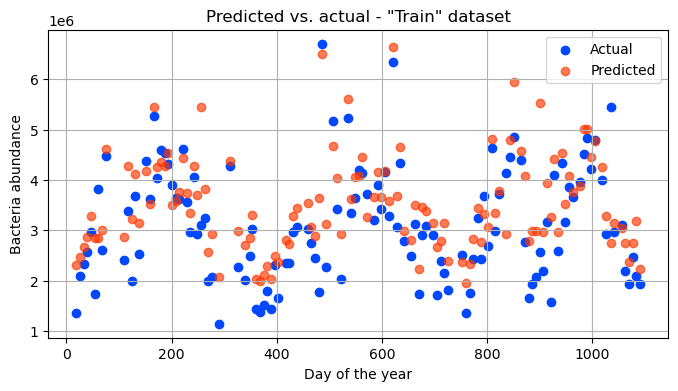

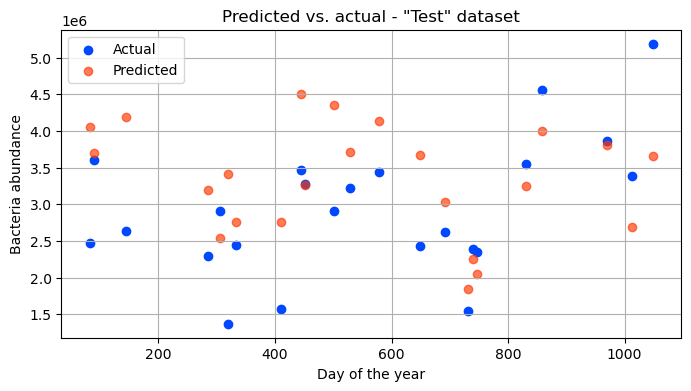

In [204]:
for (name, X, y) in [("Train", X_train, y_train), ("Test", X_test, y_test)]:
    results_df = X.copy()
    results_df["target_actual"] = y.copy()
    results_df["target_predicted"] = pipeline.predict(X)
    results_df = results_df.sort_values(by="YearDay")

    plt.figure(figsize=(8, 4))
    plt.scatter(results_df["YearDay"], results_df["target_actual"], color="#0048FF", label="Actual")
    plt.scatter(results_df["YearDay"], results_df["target_predicted"], color="#FF3700A7", label="Predicted")
    plt.xlabel("Day of the year")
    plt.ylabel("Bacteria abundance")
    plt.legend()
    plt.title(f"Predicted vs. actual - \"{name}\" dataset")
    plt.grid()
    plt.show()

<h1>References</h1>

<p>[1] Yung Lab. (2026). <a href="https://www.charmaineyung.com/" target="_blank">https://www.charmaineyung.com/</a> (Accessed online: 30.03.2026)</p>
<p>[2] Ward, C., Yung, CM., Davis, K. et al. Annual community patterns are driven by seasonal switching between closely related marine bacteria. ISME J 11, 1412–1422 (2017). <a href="https://doi.org/10.1038/ismej.2017.4" target="_blank">https://doi.org/10.1038/ismej.2017.4</a> (Accessed online: 30.03.2026)</p>
<p>[3] scikit-learn developers. (2026). <a href="https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html" target="_blank">https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html</a> (Accessed online: 30.03.2026)</p>